# PROYECTO FINAL: TELECOMUNICACIONES - IDENTIFICACIÓN DE OPERADORES INEFICACES
## OBJETIVO
#### Desarrollar un análisis integral para identificar operadores ineficaces en el servicio de telefonía virtual CallMeMaybe mediante el análisis de patrones de llamadas perdidas, tiempos de espera y volumen de llamadas salientes, aplicando técnicas de análisis exploratorio de datos y pruebas de hipótesis estadísticas.

## ANALISIS DEL PROYECTO
### FASE 1: EXPLORACIÓN Y PREPARACIÓN DE DATOS

In [35]:
# Se importa las librerias necesarias para el analisis siguiente

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu

In [3]:
# Se inicia leyendo los datasets 

dataset = pd.read_csv("telecom_dataset_new.csv")
clients = pd.read_csv("telecom_clients.csv")

In [4]:
# Se procede a analizar la estructura del dataframe dataset

dataset.info()
print(dataset.shape)
print()
print(dataset.head(20))

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB
(53902, 9)

    user_id                       date direction internal  operator_id  \
0    166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1    166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2    166377  2019-08-05 00:00:00+03:00  

El df datasets tiene 53902 filas y 9 columnas. En la columna operator_id hay solamente 45730 datos, hay 8172 valores ausentes. Se decidirá a continuación que hacer con estos datos. En cuanto al tipo de datos, se necesita transformar los datos de la columna date, de str a datetime64 y los datos de la columna internal, de obj a bool. Esto se realiza al inicio para después poder trabajar con estos datos sin ningún inconveniente.

In [5]:
# Se transforman los datos de las columnas date e internal de datasets y se verifica su cambio

dataset['date'] = pd.to_datetime(dataset['date'])
dataset['internal'] = dataset['internal'].astype('bool')
print(dataset.dtypes)

user_id                                    int64
date                   datetime64[us, UTC+03:00]
direction                                    str
internal                                    bool
operator_id                              float64
is_missed_call                              bool
calls_count                                int64
call_duration                              int64
total_call_duration                        int64
dtype: object


In [6]:
# Se reemplaza los valores ausentes por 0 y se transfroma su tipo a enteros para continuar con el analisis

dataset['operator_id'] = dataset['operator_id'].fillna(0)
dataset['operator_id'] = dataset['operator_id'].astype(int)

In [7]:
# Se procede a analizar la estructura del dataframe clients

clients.info()
print(clients.shape)
print()
print(clients.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB
(732, 3)

   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16
5   167764           A  2019-09-30
6   167050           A  2019-08-29
7   168252           A  2019-10-17
8   168495           A  2019-10-28
9   167879           A  2019-10-03


El dataframe contiene 732 filas y 3 columnas, no se encuentran datos ausentes en este dataframe, se revisa el tipo de datos y se procede a su transformacion, la columna date_start, se cambia de str a datetime64.

In [8]:
# Se transforman los datos de las columna date_start de clients y se verifica su cambio

clients['date_start'] = pd.to_datetime(clients['date_start'])
print(clients.dtypes)

user_id                 int64
tariff_plan               str
date_start     datetime64[us]
dtype: object


In [9]:
# Se analiza si existen datos duplicados en los dataframes y se decide que hacer con ellos

print(dataset.duplicated().sum())
print(clients.duplicated().sum())

4900
0


Existen 4900 datos duplicados en el dataframe datasets, y cero datos duplicados en el dataframe clients

In [10]:
# Se imprime una muestra de la tabla para entender que son los valores duplicados y decidir que realizar
duplicated_sample = dataset[dataset.duplicated(keep=False)].head(10)
print(duplicated_sample)

    user_id                      date direction  internal  operator_id  \
6    166377 2019-08-05 00:00:00+03:00       out     False       880020   
8    166377 2019-08-05 00:00:00+03:00       out     False       880020   
27   166377 2019-08-12 00:00:00+03:00        in     False            0   
28   166377 2019-08-12 00:00:00+03:00        in     False            0   
38   166377 2019-08-14 00:00:00+03:00        in     False            0   
43   166377 2019-08-14 00:00:00+03:00       out     False       880026   
44   166377 2019-08-14 00:00:00+03:00       out     False       880026   
45   166377 2019-08-14 00:00:00+03:00        in     False            0   
46   166377 2019-08-15 00:00:00+03:00       out     False       880026   
51   166377 2019-08-15 00:00:00+03:00       out     False       880026   

    is_missed_call  calls_count  call_duration  total_call_duration  
6             True            8              0                   50  
8             True            8              

Se procede a eliminar los datos duplicados luego de comprobar que son del mismo usuario y hay un patron donde se repiten 2 veces y no se necesita para el analisis ya que puede afectar de manera negativa si se tienen dos registros idénticos de todo. 

In [11]:
# Se elimina los datos duplicados y se comprueba esta accion
dataset_new = dataset.drop_duplicates()
print(dataset_new.duplicated().sum())

0


### FASE 2: ANÁLISIS EXPLORATORIO DE DATOS

In [12]:
# Se analiza la cantidad de llamadas entrantes perdidas (internas y externas) por operador

lost_calls_in = dataset_new[(dataset_new['direction'] == 'in') & (dataset_new['is_missed_call'] == True)]
lost_calls_operator = lost_calls_in.groupby('operator_id')['user_id'].count()
result_descendent = lost_calls_operator.sort_values(ascending=False)
print(result_descendent)


operator_id
0         7202
913942      28
885890      21
885876      17
944216      16
          ... 
958452       1
959312       1
960620       1
964510       1
969272       1
Name: user_id, Length: 240, dtype: int64


Se observa aqui que los 5 operadores con mayor numero de llamas perdidas son 913942.0, con 28 llamadas perdidas, 885890.0 con 21 llamadas perdidas, 885876.0 con 17 llamadas perdidas, 944216.0 con 16 llamadas perdidas y 940588.0 con 15 llamadas perdidas.

In [13]:
# Se calcula el tiempo de espera de las llamadas entrantes

dataset_new['waiting_time'] = dataset_new['total_call_duration'] - dataset_new['call_duration']
waiting_time_operator = dataset_new.groupby('operator_id')['waiting_time'].sum()
result_descendent = waiting_time_operator.sort_values(ascending=False)
print(result_descendent)

operator_id
885890    1443002
885876    1369284
0         1269085
925922     423767
929428     356078
           ...   
946454          0
955068          0
914626          0
958458          0
960674          0
Name: waiting_time, Length: 1093, dtype: int64


In [14]:
# Se analiza el numero de llamadas salientes por operador 

calls_out = dataset_new[dataset_new['direction'] == 'out']
calls_out_operator = calls_out.groupby('operator_id')['user_id'].count()
result_descendent = calls_out_operator.sort_values(ascending=False)
print(result_descendent)


operator_id
901884    228
887276    198
901880    194
885876    193
891410    191
         ... 
914256      1
962904      1
969262      1
909452      1
907998      1
Name: user_id, Length: 883, dtype: int64


In [15]:
# Se unen los tres análisis en un solo DataFrame para poder graficar y continuar con el analisis
performance_df = pd.DataFrame({'lost_calls': lost_calls_operator,'total_waiting_time': waiting_time_operator,
                               'outgoing_calls': calls_out_operator}).fillna(0)
print(performance_df)
performance_df.info()

             lost_calls  total_waiting_time  outgoing_calls
operator_id                                                
0                7202.0             1269085           186.0
879896              0.0               12275            96.0
879898              0.0              103897           170.0
880020              0.0                 280            13.0
880022              0.0                3778            62.0
...                 ...                 ...             ...
972410              0.0                1498             4.0
972412              0.0                1050             4.0
972460              0.0                 620             6.0
973120              0.0                  20             2.0
973286              0.0                  88             0.0

[1093 rows x 3 columns]
<class 'pandas.DataFrame'>
Index: 1093 entries, 0 to 973286
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   

Se evidencia aqui el tratamiento que se hizo a los datos ausentes, el operator_id ahora contiene los datos que no fueron asignados a ningun operador, hay alguna falla en el sistema de las llamadas, lost_calls son en tontal 7202.0, total_waiting_time es 1269085 y outgoing_calls son 186.0. Se debe separar esta información, así se puede analiar a futuro algún error que tenga el sistema y se mantiene la información solo de operadores reales.

In [16]:
# Se filtra para obtener solo los IDs de operadores
df_operators = performance_df.drop(index=0.0, errors='ignore')
# Se guarda la fila del 0.0 para reportar llamadas sin asignar
df_system = performance_df.loc[[0.0]]

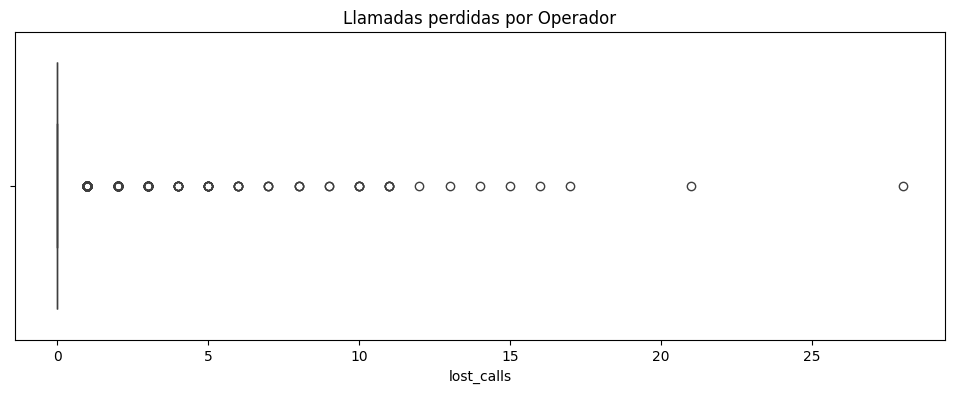

In [17]:
# Se realiza gráficos a continuación que serán de gran validez para entender el análisis anterior 
# Gráfico de llamadas perdidasd por operador
plt.figure(figsize=(12,4))
sns.boxplot(x=df_operators['lost_calls'])
plt.title('Llamadas perdidas por Operador')
plt.show()

Mediante este gráfico de boxplot se puede evidenciar que la mayoria de operadores se encuentran entre 0 y 5 llamadas perdidas, hay un número considerable de quienes sobrepasan y llegan hasta 15 llamadas perdidas, pero también existen operadores que excenden y serían los más ineficientes ya que más de 15 e incluso más de 25 llamadas perdidas.

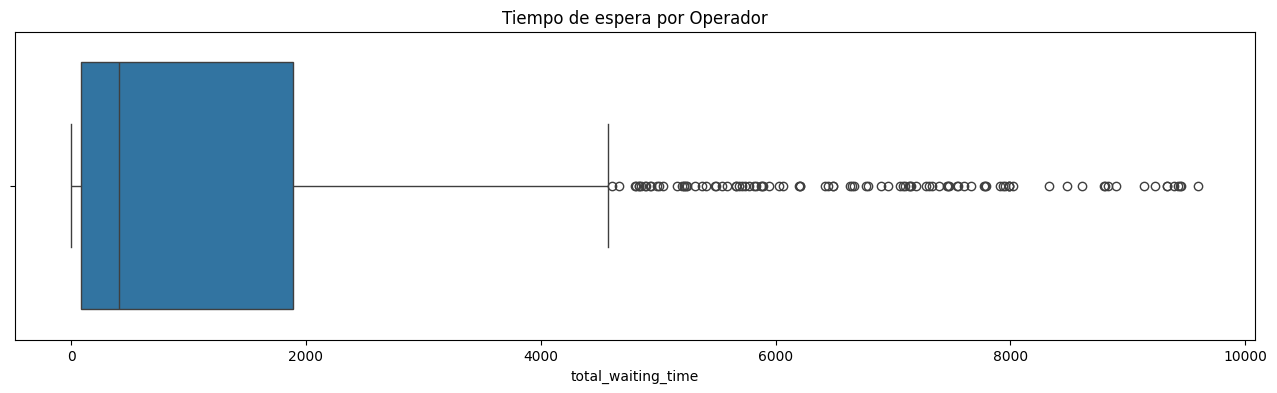

In [18]:
# Gráfico de tiempo de espera por operador
plt.figure(figsize=(16,4))
df_operators_limit = df_operators[df_operators['total_waiting_time'] < 10000]
sns.boxplot(x=df_operators_limit['total_waiting_time'])
plt.title('Tiempo de espera por Operador')
plt.show()

En cuanto al tiempo de espera por operador, se ve que el 75% de los operadores mantienen un tiempo de espera acumulado por debajo de los 2,000 unidades, existe un grupo crítico de operadores que alcanzan valores de hasta 10,000. Estos individuos representan fallas severas en la eficiencia del servicio y deben ser el foco principal de la reestructuración. Estos operadores están haciendo esperar a los clientes 5 veces más que el promedio llegando casi a los 10,000.

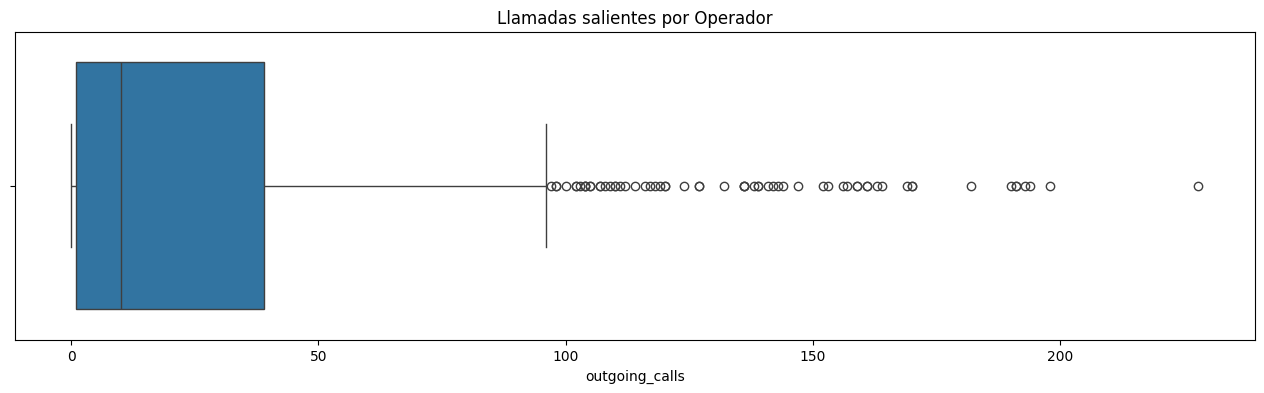

In [19]:
# Gráfico de llamadas salientes por operador
plt.figure(figsize=(16,4))
sns.boxplot(x=df_operators['outgoing_calls'])
plt.title('Llamadas salientes por Operador')
plt.show()

Las llamadas salientes por operador, la mediana es muy baja comparada con los valores máximos, esto puede indicar que una gran parte de la fuerza laboral es pasiva o se dedica principalmente a recibir llamadas en lugar de realizarlas. El 75% de los operadores hace menos de 50 llamadas. Esto establece una baja actividad saliente para la mayoría. Aquí los puntos atípicos son los operadores mas eficaces en términos de proactividad hay operadores que superan las 100 e incluso llegan a las 200 llamadas salientes.

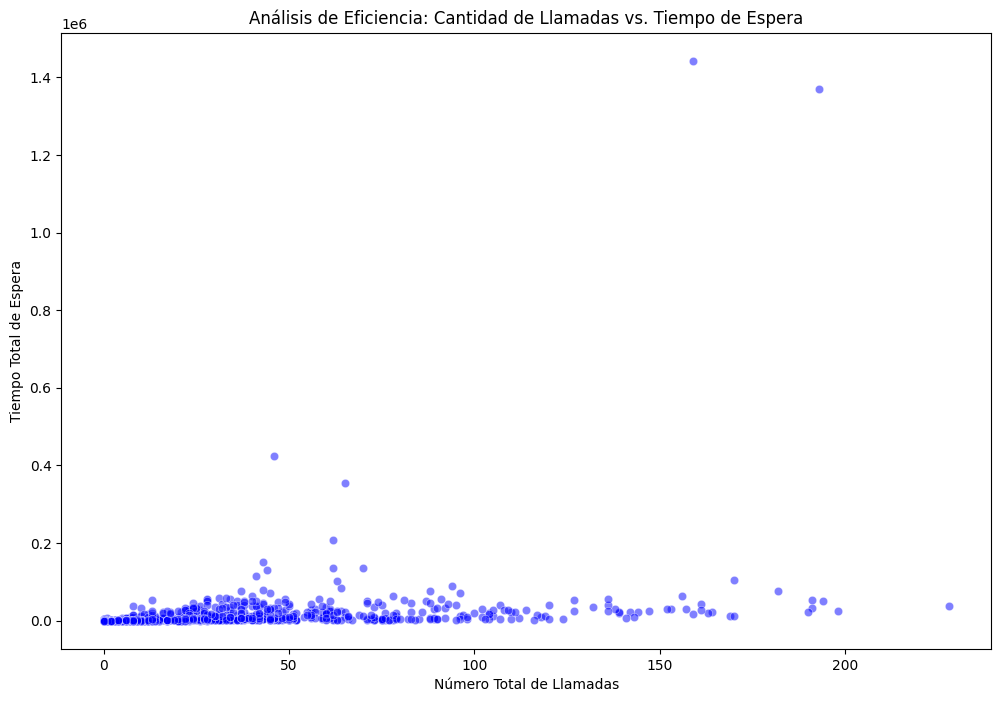

In [29]:
# Se realiza un grafico para tener la informacion compuesta por las llamadas salientes y el tiempo de espera

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df_operators, 
    x='outgoing_calls', 
    y='total_waiting_time',
    alpha=0.5,
    color='blue')

# Añadimos etiquetas claras
plt.title('Análisis de Eficiencia: Cantidad de Llamadas vs. Tiempo de Espera')
plt.xlabel('Número Total de Llamadas')
plt.ylabel('Tiempo Total de Espera')

plt.show()

La gran mayoría de los operadores se concentra en la base del gráfico, manteniendo tiempos de espera mínimos (cercanos a 0) con un volumen de actividad de hasta 50 llamadas. Existe un grupo de operadores que manejan entre 50 y 150 llamadas sin que su tiempo de espera se incremente significativamente. Los puntos aislados en la parte superior del gráfico presentan el mayor volumen de actividad (superior a las 150 llamadas) pero que, simultáneamente, generan los tiempos de espera más altos del dataset. Si bien su productividad en llamadas es superior al promedio, el crecimiento del tiempo de espera es desproporcionado.

### FASE 3: HIPOTESIS ESTADISTICAS

In [34]:
# Se calcula la desviacion de la normalidad por medio de Shapiro-Wilk
alpha= 0.05
stat, p = stats.shapiro(df_operators['total_waiting_time'])
print (p)

3.542731596335176e-57


In [38]:
# Se prueba la hipotesis estadistica de las llamadas perdidas vs el tiempo de espera
# Se definen los grupos en base a su timepo de espera badado en los graficos anteriores

grupo_espera_alta = df_operators[df_operators['total_waiting_time'] > 2000]['lost_calls']
grupo_espera_baja = df_operators[df_operators['total_waiting_time'] <= 2000]['lost_calls']

stat, p_mu = mannwhitneyu(grupo_espera_alta, grupo_espera_baja)

print(p_mu)

if p_mu < 0.05:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa en las llamadas perdidas entre ambos grupos.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia de que la espera afecte a las llamadas perdidas.")

2.946701313107387e-23
Rechazamos la hipótesis nula: Hay una diferencia significativa en las llamadas perdidas entre ambos grupos.


El p_value es mucho menor al valor alpha de 0.05, entonces existe evidencia estadística de que los operadores con altos tiempos de espera tienen un desempeño significativamente peor en la retención de llamadas, acumulando más llamadas perdidas.

In [40]:
# Definimos los grupos basados en tu análisis previo de ineficacia (ej. espera > 2000)
ineficientes = df_operators[df_operators['total_waiting_time'] > 2000]['outgoing_calls']
eficientes = df_operators[df_operators['total_waiting_time'] <= 2000]['outgoing_calls']

stat, p = stats.mannwhitneyu(ineficientes, eficientes)

print(p)

if p < 0.05:
    print("Rechazamos la hipótesis nula: Existe una diferencia estadística en las llamadas salientes de ambos grupos.")
else:
    print("No se rechaza la hipótesis nula: No hay evidencia de que la ineficacia en espera afecte el volumen de llamadas salientes.")

3.9959579869936816e-131
Rechazamos la hipótesis nula: Existe una diferencia estadística en las llamadas salientes de ambos grupos.


El p value también es mucho menor que valor alpha de 0.05. Se rechaza la hipótesis nula, existe evidencia estadística de que los operadores ineficientes no solo fallan en las llamadas entrantes, sino que muestran un nivel de actividad saliente significativamente menor comparado con los operadores eficientes.

### FASE 4: CONCLUSIONES Y RECOMENDACIONES

Luego de analizar los datos de CallMeMaybe, se han validado las métricas para identificar la ineficacia operativa. Se confirmó estadísticamente que la ineficacia no es aislada. Los operadores con tiempos de espera excesivos (outliers identificados sobre las 2,000 unidades) también presentan una tasa significativamente mayor de llamadas perdidas y una baja proactividad en llamadas salientes.

Las pruebas de Mann-Whitney U rechazaron las hipótesis nulas con p-values extremadamente bajos, lo que garantiza que las diferencias de rendimiento encontradas son producto de deficiencias reales en el desempeño. Se identificaron operadores específicos como se ve en el Scatter Plot, que a pesar de tener un volumen de llamadas aceptable, saturan el sistema con tiempos de espera desproporcionados, afectando la calidad global del servicio.

Se puede investigar más a fondo a los operadores de alta productividad que presentan esperas elevadas, ya que podrían estar sufriendo de saturación de tareas.
Se recomienda utilizar el dashboard desarrollado para realizar un seguimiento de estas métricas y detectar alertas tempranas de ineficacia antes de que afecten el promedio.